In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df = df.iloc[:,1:]

In [5]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
encoder = LabelEncoder()

In [9]:
df['Species'] = encoder.fit_transform(df['Species'])

In [10]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [13]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm',"Species"]]

In [14]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [15]:
import seaborn as sns

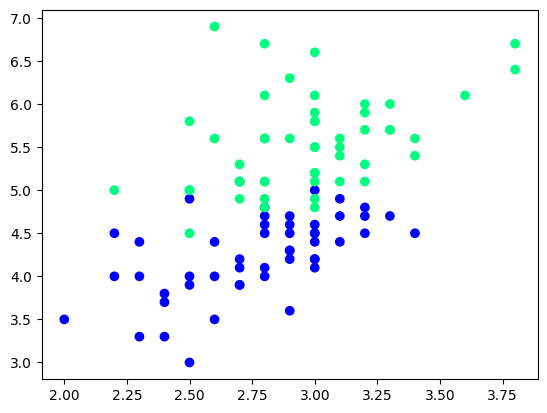

In [16]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'], c= df['Species'],cmap = 'winter')

In [17]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [18]:
df_train

,SepalWidthCm,PetalLengthCm,Species
125,3.2,6.0,2
100,3.3,6.0,2
87,2.3,4.4,1
141,3.1,5.1,2
132,2.8,5.6,2
77,3.0,5.0,1
104,3.0,5.8,2
52,3.1,4.9,1
136,3.4,5.6,2
140,3.1,5.6,2


In [20]:
X_test = df_test.iloc[:,:-1].values
y_test = df_test.iloc[:,-1].values

In [21]:
X_test

array([[3. , 6.6],
       [3.3, 4.7],
       [2.6, 4. ],
       [2.8, 4.8],
       [2.6, 4.4]])

In [22]:
y_test

array([2, 1, 1, 1, 1])

## Case1 - Bagging

In [25]:
df_bag = df_train.sample(8,replace = True) ## Random Sample of 80% of Dat with Relacenment
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,SepalWidthCm,PetalLengthCm,Species
141,3.1,5.1,2
77,3.0,5.0,1
52,3.1,4.9,1
100,3.3,6.0,2
125,3.2,6.0,2
100,3.3,6.0,2
125,3.2,6.0,2
136,3.4,5.6,2


In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [29]:
df_bag1 = DecisionTreeClassifier()

In [34]:
def evaluate(model,X,y):
    model.fit(X,y)
    plot_tree(model)
    plt.show()
    plot_decision_regions(X.values,y.values,model)
    plt.show()
    y_pred = model.predict(X_test)
    print(accuracy_score(y_test,y_pred))

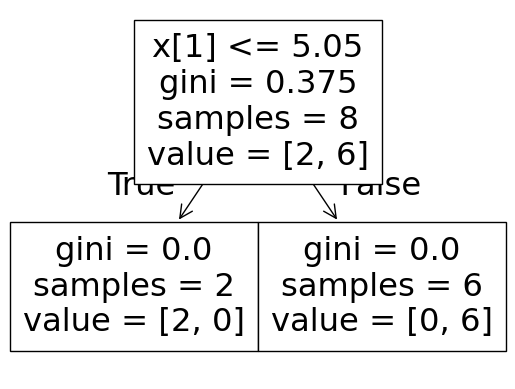

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


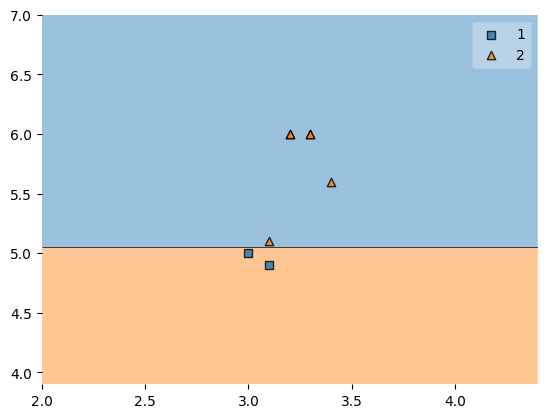

1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [35]:
evaluate(df_bag1,X,y)

In [36]:
df_bag = df_train.sample(8,replace = True) ## Random Sample of 80% of Dat with Relacenment
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,SepalWidthCm,PetalLengthCm,Species
136,3.4,5.6,2
132,2.8,5.6,2
136,3.4,5.6,2
104,3.0,5.8,2
140,3.1,5.6,2
132,2.8,5.6,2
125,3.2,6.0,2
52,3.1,4.9,1


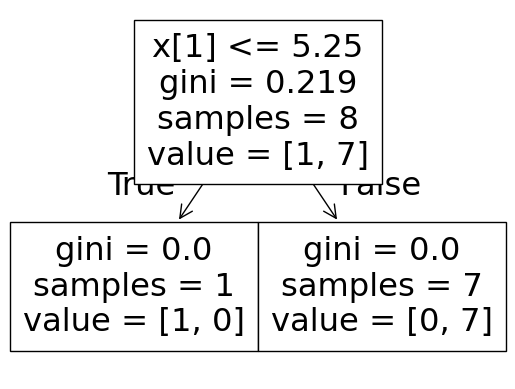

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


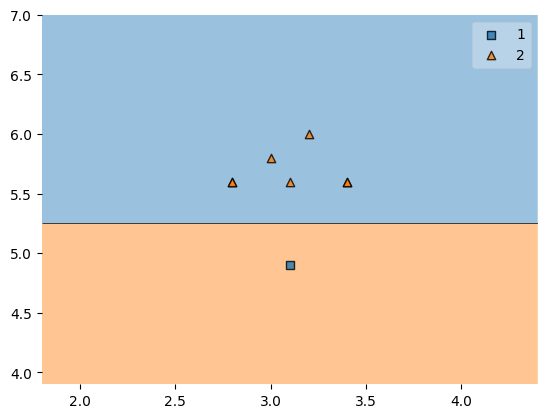

1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [37]:
df2 = DecisionTreeClassifier()
evaluate(df2,X,y)

In [38]:
df_bag = df_train.sample(8,replace = True) ## Random Sample of 80% of Dat with Relacenment
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,SepalWidthCm,PetalLengthCm,Species
77,3.0,5.0,1
77,3.0,5.0,1
140,3.1,5.6,2
104,3.0,5.8,2
125,3.2,6.0,2
52,3.1,4.9,1
125,3.2,6.0,2
52,3.1,4.9,1


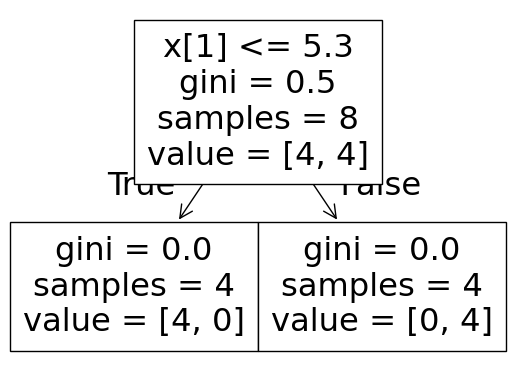

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


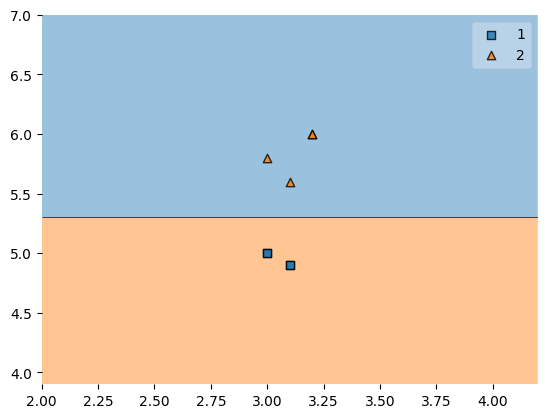

1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [39]:
df3 = DecisionTreeClassifier()
evaluate(df3,X,y)

## Predict

In [40]:
df_test

,SepalWidthCm,PetalLengthCm,Species
105,3.0,6.6,2
56,3.3,4.7,1
92,2.6,4.0,1
76,2.8,4.8,1
90,2.6,4.4,1


In [42]:
print('Predictor 1',df_bag1.predict(np.array([3.0,6.6]).reshape(1,-1)))
print('Predictor 2',df2.predict(np.array([3.0,6.6]).reshape(1,-1)))
print('Predictor 3',df3.predict(np.array([3.0,6.6]).reshape(1,-1)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Pasting


In Bagging, We pass Random Data with Replacement, But in Pasting we pass random data without replacement

In [43]:
df_bag = df_train.sample(8,replace = False) ## Random Sample of 80% of Dat without Relacenment
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,SepalWidthCm,PetalLengthCm,Species
125,3.2,6.0,2
87,2.3,4.4,1
140,3.1,5.6,2
136,3.4,5.6,2
52,3.1,4.9,1
141,3.1,5.1,2
77,3.0,5.0,1
132,2.8,5.6,2


## Random Sequnces

In [45]:
df1 = pd.read_csv("Iris.csv")

In [46]:
df1 = df1.sample(10)

In [47]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
107,108,7.3,2.9,6.3,1.8,Iris-virginica
75,76,6.6,3.0,4.4,1.4,Iris-versicolor
29,30,4.7,3.2,1.6,0.2,Iris-setosa
26,27,5.0,3.4,1.6,0.4,Iris-setosa
86,87,6.7,3.1,4.7,1.5,Iris-versicolor
102,103,7.1,3.0,5.9,2.1,Iris-virginica
141,142,6.9,3.1,5.1,2.3,Iris-virginica
35,36,5.0,3.2,1.2,0.2,Iris-setosa
88,89,5.6,3.0,4.1,1.3,Iris-versicolor
42,43,4.4,3.2,1.3,0.2,Iris-setosa


In [48]:
df1.sample(2,replace = True,axis = 1)

,PetalWidthCm,Species
107,1.8,Iris-virginica
75,1.4,Iris-versicolor
29,0.2,Iris-setosa
26,0.4,Iris-setosa
86,1.5,Iris-versicolor
102,2.1,Iris-virginica
141,2.3,Iris-virginica
35,0.2,Iris-setosa
88,1.3,Iris-versicolor
42,0.2,Iris-setosa
